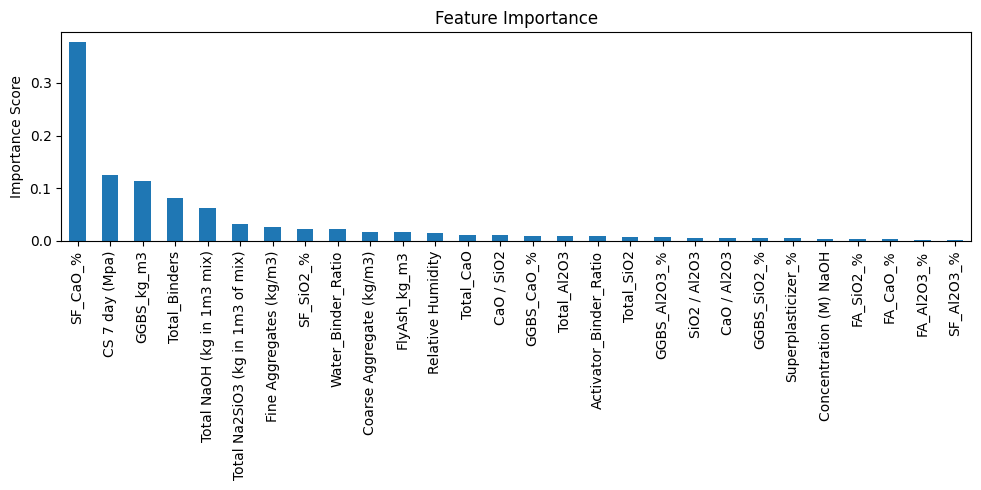

In [1]:
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('../data/trial_engineered_ds.csv')
X = df.drop("CS 28 day (Mpa)", axis=1)
y = df['CS 28 day (Mpa)']

# Train model
model = RandomForestRegressor(random_state=42)
model.fit(X, y)

# Feature importance
importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

# Plot
plt.figure(figsize=(10,5))
importance.plot(kind='bar')
plt.title("Feature Importance")
plt.ylabel("Importance Score")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Linear Regression

In [2]:
df = pd.read_csv('../data/trial_engineered_ds.csv')
print(df.shape)
df.head()

(445, 29)


,GGBS_kg_m3,GGBS_CaO_%,GGBS_SiO2_%,GGBS_Al2O3_%,FlyAsh_kg_m3,FA_CaO_%,FA_SiO2_%,FA_Al2O3_%,SF_CaO_%,SF_SiO2_%,...,Relative Humidity,CS 7 day (Mpa),CS 28 day (Mpa),Total_Binders,Total_SiO2,Total_CaO,Total_Al2O3,SiO2 / Al2O3,CaO / Al2O3,CaO / SiO2
0,0.0,47.75,27.17,8.6,650.0,15.48,48.43,17.15,0.0,0.0,...,60.0,34.0,29.00,650.0,48.43,15.480,17.150,2.823907,2.823907,0.319637
1,650.0,47.75,27.17,8.6,0.0,15.48,48.43,17.15,0.0,0.0,...,60.0,34.0,40.00,650.0,27.17,47.750,8.600,3.159302,3.159302,1.757453
2,325.0,47.75,27.17,8.6,325.0,15.48,48.43,17.15,0.0,0.0,...,60.0,34.0,45.00,650.0,37.80,31.615,12.875,2.935922,2.935922,0.836376
3,0.0,47.75,27.17,8.6,637.0,15.48,48.43,17.15,0.0,0.0,...,60.0,34.0,48.00,637.0,48.43,15.480,17.150,2.823907,2.823907,0.319637
4,637.0,47.75,27.17,8.6,0.0,15.48,48.43,17.15,0.0,0.0,...,60.0,34.0,50.32,637.0,27.17,47.750,8.600,3.159302,3.159302,1.757453


In [3]:
(df.isnull().mean())*100

GGBS_kg_m3                          0.0
GGBS_CaO_%                          0.0
GGBS_SiO2_%                         0.0
GGBS_Al2O3_%                        0.0
FlyAsh_kg_m3                        0.0
FA_CaO_%                            0.0
FA_SiO2_%                           0.0
FA_Al2O3_%                          0.0
SF_CaO_%                            0.0
SF_SiO2_%                           0.0
SF_Al2O3_%                          0.0
Total NaOH (kg in 1m3 mix)          0.0
Concentration (M) NaOH              0.0
Total Na2SiO3 (kg in 1m3 of mix)    0.0
Coarse Aggregate (kg/m3)            0.0
Fine Aggregates (kg/m3)             0.0
Activator_Binder_Ratio              0.0
Water_Binder_Ratio                  0.0
Superplasticizer_%                  0.0
Relative Humidity                   0.0
CS 7 day (Mpa)                      0.0
CS 28 day (Mpa)                     0.0
Total_Binders                       0.0
Total_SiO2                          0.0
Total_CaO                           0.0


In [4]:
X = df.drop("CS 28 day (Mpa)", axis=1)
y = df['CS 28 day (Mpa)']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test  = sc.transform(X_test)

from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)

from sklearn.metrics import r2_score, mean_squared_error
print(" R2:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

 R2: 0.769444200910108
RMSE: 15.50770280427097


## Random Forest

In [5]:
df = pd.read_csv('../data/trial_engineered_ds.csv')
X = df.drop("CS 28 day (Mpa)", axis=1)
y = df['CS 28 day (Mpa)']


from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test  = sc.transform(X_test)

In [6]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    max_features='sqrt',
    
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

from sklearn.metrics import r2_score, mean_squared_error
print("Random Forest R2:", r2_score(y_test, y_pred_rf))
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

Random Forest R2: 0.8755246972042198
Random Forest RMSE: 11.394651314277633


In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Parameter grid
param_grid = {
    "n_estimators": [50, 100, 200, 300, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf = RandomForestRegressor(random_state=42)

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    n_jobs=-1,
    scoring="r2"
)

grid.fit(X_train, y_train)

# Best model
best_rf = grid.best_estimator_

# Prediction
y_pred_rf = best_rf.predict(X_test)

# Evaluation
print("Best Params:", grid.best_params_)
print("Random Forest R2:", r2_score(y_test, y_pred_rf))
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

Best Params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}
Random Forest R2: 0.8760342234029236
Random Forest RMSE: 11.371306012601455


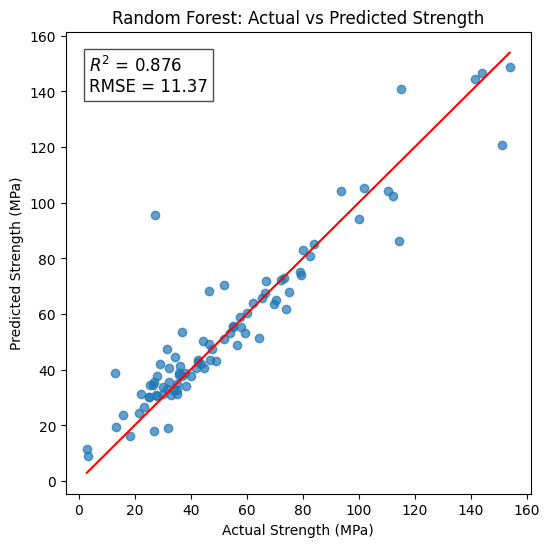

In [8]:
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_rf, alpha=0.7)

plt.xlabel("Actual Strength (MPa)")
plt.ylabel("Predicted Strength (MPa)")
plt.title("Random Forest: Actual vs Predicted Strength")

# perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='-')

# metrics text
text = f"$R^2$ = {r2_rf:.3f}\nRMSE = {rmse_rf:.2f}"

plt.text(0.05, 0.95,
         text,
         transform=plt.gca().transAxes,
         fontsize=12,
         verticalalignment='top',
         bbox=dict(facecolor='white', alpha=0.7))

plt.show()

In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

# Model
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    max_features='sqrt',
    
)

# K-Fold setup
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

# Cross validation (R2)
cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=kfold,
    scoring="r2",
    n_jobs=-1
)

print("CV Scores:", cv_scores)
print("Mean CV R2:", np.mean(cv_scores))
print("Std CV:", np.std(cv_scores))

CV Scores: [0.86425464 0.883371   0.87714324 0.60354957 0.86200543 0.72476685
 0.90562327 0.87730334 0.79585876 0.78709392]
Mean CV R2: 0.818097003753303
Std CV: 0.0889768038276012


In [10]:
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

In [11]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Model
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.78,
    colsample_bytree=0.8,
    random_state=42
)

# Train
xgb_model.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb_model.predict(X_test)

# Evaluation
print("XGBoost R2:", r2_score(y_test, y_pred_xgb))
print("XGBoost RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))

XGBoost R2: 0.915861472998279
XGBoost RMSE: 9.368216021436062


In [12]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Model
xgb = XGBRegressor(random_state=42)

# Parameter grid
param_grid = {
    "n_estimators": [200, 400, 600],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

# Grid search
grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=10,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

# Best model
best_xgb = grid.best_estimator_

# Prediction
y_pred = best_xgb.predict(X_test)

# Evaluation
print("Best Params:", grid.best_params_)
print("R2:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Fitting 10 folds for each of 108 candidates, totalling 1080 fits
Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 400, 'subsample': 0.8}
R2: 0.9098518696182657
RMSE: 9.697009170422852


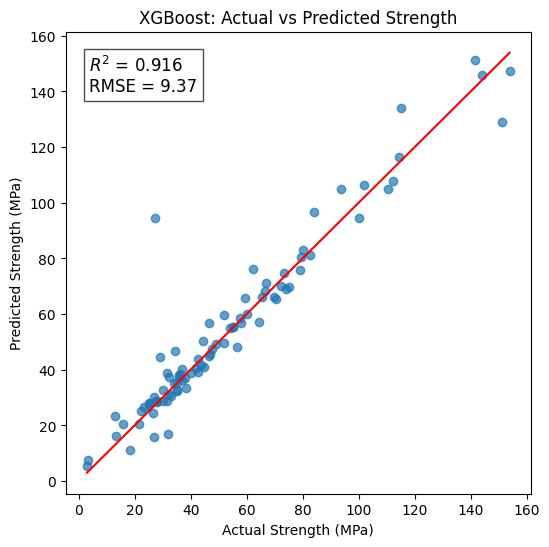

In [15]:
r2 = r2_score(y_test, y_pred_xgb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_xgb, alpha=0.7)

plt.xlabel("Actual Strength (MPa)")
plt.ylabel("Predicted Strength (MPa)")
plt.title("XGBoost: Actual vs Predicted Strength")

# perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='-')

# metrics text
text = f"$R^2$ = {r2:.3f}\nRMSE = {rmse:.2f}"

plt.text(0.05, 0.95,
         text,
         transform=plt.gca().transAxes,
         fontsize=12,
         verticalalignment='top',
         bbox=dict(facecolor='white', alpha=0.7))

plt.show()